In [132]:
import warnings

from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt
import numpy as np

# Benign matplotlib rendering warning from marker-size scaling under the
# inline backend (data is finite; plots render correctly). Silence just this one.
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in sqrt",
    category=RuntimeWarning,
)

In [133]:
x, color = make_swiss_roll(n_samples=2000, random_state=42)

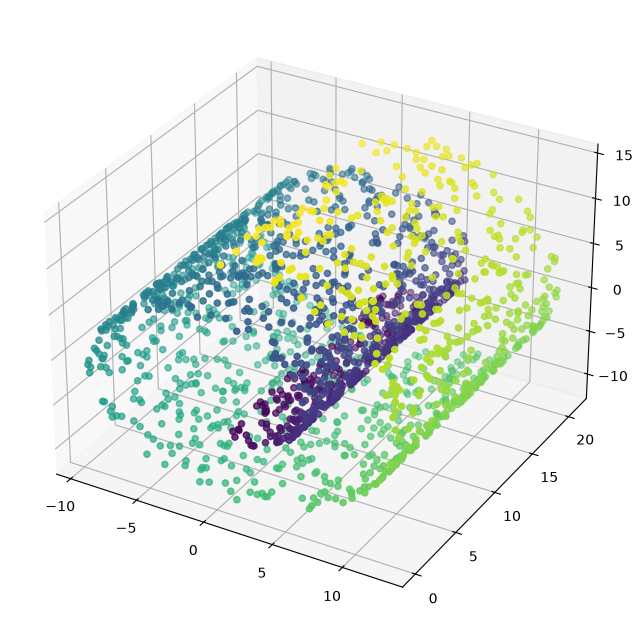

In [143]:
fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(projection='3d')
ax.scatter(x[:, 0], x[:, 1], x[:, 2], c=color, cmap=plt.cm.viridis)
plt.show()

In [135]:
# First 1000 samples -> PCA
x_pca_data = x[:1000]
color_pca = color[:1000]

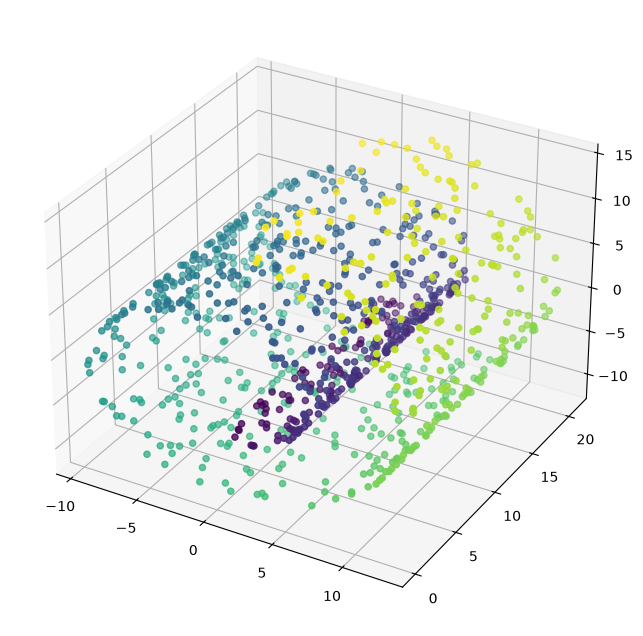

In [136]:
fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(projection='3d')
ax.scatter(x_pca_data[:, 0], x_pca_data[:, 1], x_pca_data[:, 2], c=color_pca, cmap=plt.cm.viridis)
plt.show()

In [137]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_pca_data)

pca_error = 1 - np.sum(pca.explained_variance_ratio_)

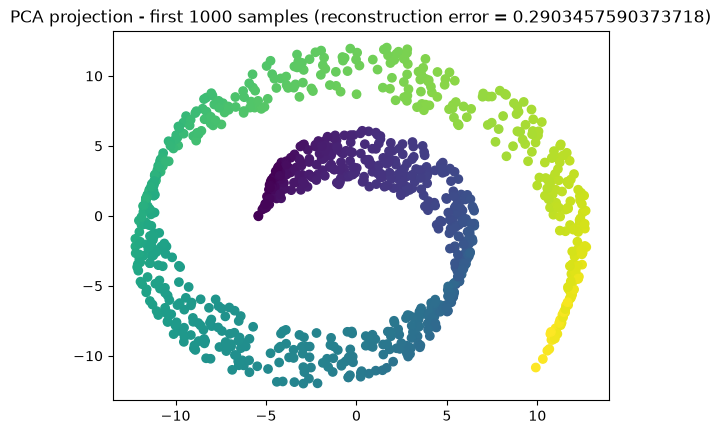

In [138]:
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=color_pca, cmap=plt.cm.viridis)
plt.title(f'PCA projection - first 1000 samples (reconstruction error = {pca_error})')
plt.show()

In [139]:
from sklearn.manifold import LocallyLinearEmbedding

# second 1000 samples -> LLE

x_lle_data = x[1000:]
color_lle = color[1000:]

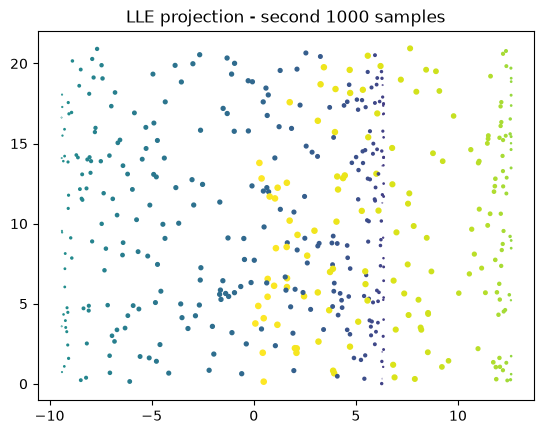

In [140]:
plt.scatter(x_lle_data[:, 0], x_lle_data[:, 1], x_lle_data[:, 2], c=color_lle, cmap=plt.cm.viridis)
plt.title(f'LLE projection - second 1000 samples')
plt.show()

In [141]:

lle = LocallyLinearEmbedding(n_components=2, n_neighbors=12)
x_lle = lle.fit_transform(x_lle_data)
lle_error = lle.reconstruction_error_

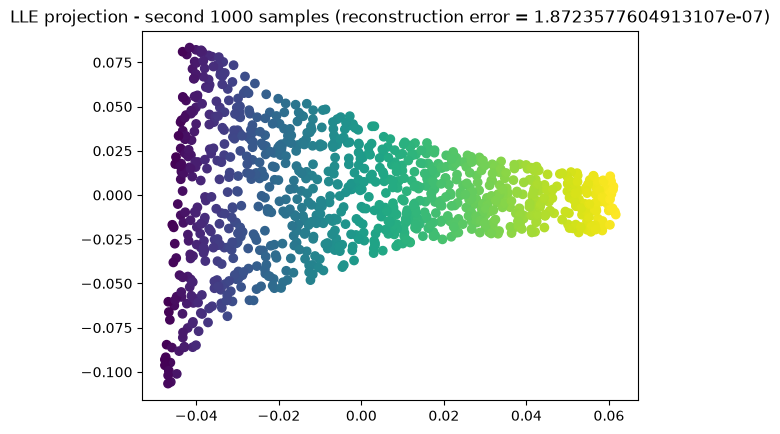

In [142]:
plt.scatter(x_lle[:, 0], x_lle[:, 1], c=color_lle, cmap=plt.cm.viridis)
plt.title(f'LLE projection - second 1000 samples (reconstruction error = {lle_error})')
plt.show()

## Summary

- Generated a **Swiss roll** (2000 points, 3D) — a classic non-linear manifold.
- Applied **PCA** (linear) on the first 1000 samples and **LLE** (non-linear) on the second 1000.
- **PCA** just flattens the roll → distant parts of the sheet overlap; the color gradient folds over itself.
- **LLE** unrolls the manifold → color varies smoothly across a flat 2D strip; local neighborhoods are preserved.

**Key takeaway:** the two error numbers are *not comparable* — PCA's is variance lost in projection, LLE's is the local neighbor-reconstruction cost. For manifold data like this, **LLE preserves the intrinsic structure that linear PCA cannot**.
